# Избыток в экспериментальных данных: что это за события и почему их больше

**Тезис в одну строку.** Избыток — не новая популяция. Это горизонтальные события без трековой
структуры, которые симуляция производит и которые встречаются в обоих доменах почти одинаково
часто. **Почему из данных порог перешагивает вдвое больше — открытый вопрос**, и шаг 4
показывает, какие объяснения уже отпали.

Ниже пять шагов. Каждый — один запрос к готовым таблицам и один рисунок или таблица.
Всё измеряется от хитов; выход нейросети используется только там, где речь о самом отборе.

In [1]:
import sys, warnings
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

HERE = Path("/home/albert/Baikal2025/inference_v2/nu_classifier/analysis/excess_mechanism")
sys.path.insert(0, str(HERE))
warnings.filterwarnings("ignore")
(HERE / "figures").mkdir(exist_ok=True)

db = duckdb.connect(str(HERE / "features.duckdb"), read_only=True)
feat = db.execute("SELECT * FROM features").df()
g = {k: feat[feat.group_id == k] for k in range(1, 9)}

# Полные размеры групп в отобранной статистике (h8s3, порог скора 0.8, чёрный список применён).
# Группы 6 и 8 взяты целиком, 5 и 7 — квотная выборка, поэтому нужен вес.
FULL = {1: 5_162, 2: 525_904, 3: 12_499, 4: 1_360_695,
        5: 23_159_967, 6: 7_751, 7: 3_177_637, 8: 3_044}
W = {k: FULL[k] / len(g[k]) for k in FULL}
MU_ALL, EXP_ALL = FULL[5] + FULL[6], FULL[7] + FULL[8]

BLUE, ORANGE, AQUA, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
def style(ax):
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", linewidth=0.8); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color("#c9c8c3")
    ax.tick_params(colors=MUTED, length=0)
    return ax

print(f"{len(feat):,} событий, {feat.shape[1] - 5} признаков, все посчитаны от хитов")

628,456 событий, 52 признаков, все посчитаны от хитов


## Шаг 1. В чём избыток

Классификатор нейтрино отбирает события со скором выше 0.8. На отобранной статистике (h8s3,
проверенный чёрный список применён) он принимает **0.0335%** смоделированных атмосферных мюонов
— это его собственные ошибки, других мюонов там нет — и **0.0957%** экспериментальных событий.
Отношение **2.86**.

**Но так сравнивать нельзя, и вот почему.** Приёмка классификатора очень сильно зависит от
формы события, а формы в двух выборках распределены по-разному ещё до всякого скоринга.

Форму меряем отношением размеров облака хитов `r_vert = σ_z / √(σ_x² + σ_y²)`: велико —
событие вытянуто вертикально, мало — распластано. **Это не угол**, хотя выглядит похоже;
прочтение его как угла было главной ошибкой предыдущего исследования, и здесь он используется
только как форма.

Ниже таблица. Приёмка меняется по полосам в **две тысячи раз**, а плоских событий в данных
вдвое больше, чем в MC. Значит часть сырых 2.86 — просто разный состав выборок.

**Поправка:** взять приёмку MC внутри каждой полосы формы, применить её к числу
экспериментальных событий в той же полосе, сложить. Получается **1.97**, и это уже избыток
сверх различия составов.

Дальше ничего не зависит от того, какую из двух цифр брать. Обе относятся к одному и тому же
вопросу: **это события, которых симуляция не делает, или те же самые, но их больше?**

In [2]:
BANDS_SHAPE = [(0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.2), (1.2, 99)]
rows, observed, predicted = [], 0.0, 0.0
for lo, hi in BANDS_SHAPE:
    band = lambda d: ((d.r_vert >= lo) & (d.r_vert < hi)).values
    mc_q = W[5] * band(g[5]).sum() + W[6] * band(g[6]).sum()
    mc_s = W[6] * band(g[6]).sum()
    ex_q = W[7] * band(g[7]).sum() + W[8] * band(g[8]).sum()
    ex_s = W[8] * band(g[8]).sum()
    p = ex_q * mc_s / mc_q
    observed += ex_s; predicted += p
    rows.append({"r_vert": f"{lo}–{hi}",
                 "доля в MC": f"{100*mc_q/MU_ALL:.2f}%",
                 "доля в эксп.": f"{100*ex_q/EXP_ALL:.2f}%",
                 "состав эксп./MC": round((ex_q/EXP_ALL)/(mc_q/MU_ALL), 2),
                 "приёмка MC": f"{100*mc_s/mc_q:.4f}%",
                 "принято в эксп.": f"{ex_s:,.0f}",
                 "предсказано": f"{p:,.0f}"})
display(pd.DataFrame(rows))
print(f"наблюдено {observed:,.0f}, предсказано {predicted:,.0f}  ->  "
      f"избыток с поправкой на форму  x{observed/predicted:.2f}")
print(f"без поправки, одна общая приёмка                       x"
      f"{(FULL[8]/EXP_ALL)/(FULL[6]/MU_ALL):.2f}")
print("\nПриёмка падает в 2000 раз от плоских событий к вытянутым, а плоских в данных вдвое "
      "больше — отсюда и разница между 2.86 и 1.97.")

,r_vert,доля в MC,доля в эксп.,состав эксп./MC,приёмка MC,принято в эксп.,предсказано
0,0–0.4,0.99%,2.02%,2.05,0.6733%,464,433
1,0.4–0.6,7.71%,11.67%,1.51,0.1699%,"1,291",630
2,0.6–0.8,16.01%,18.30%,1.14,0.0610%,987,355
3,0.8–1.2,32.41%,31.94%,0.99,0.0118%,281,120
4,1.2–99,42.88%,36.08%,0.84,0.0003%,21,3


наблюдено 3,044, предсказано 1,541  ->  избыток с поправкой на форму  x1.97
без поправки, одна общая приёмка                       x2.86

Приёмка падает в 2000 раз от плоских событий к вытянутым, а плоских в данных вдвое больше — отсюда и разница между 2.86 и 1.97.


## Шаг 2. Что это за события — портрет

Четыре популяции в двух величинах, ни одна из которых не видна классификатору:

- **зенит из подгонки черенковского трека** — 0° вверх, 90° горизонт, 180° вниз. Направление
  берётся из времён, не из формы облака хитов: модули стоят на вертикальных стрингах, и главная
  ось облака почти вертикальна независимо от трека. Проверено против истины MC — медианная
  ошибка 1.0° для 42% событий и несколько градусов для 99%;
- **трековость** — r² времени против глубины: 1 = хиты на прямой, 0 = структуры нет.

Картина простая до неприличия: обычные мюоны идут круто вниз с чётким треком, нейтрино вверх с
чётким треком, а **всё, что классификатор путает, сидит у горизонта и трека не имеет вовсе**.
И в симуляции, и в данных — на одном и том же месте.

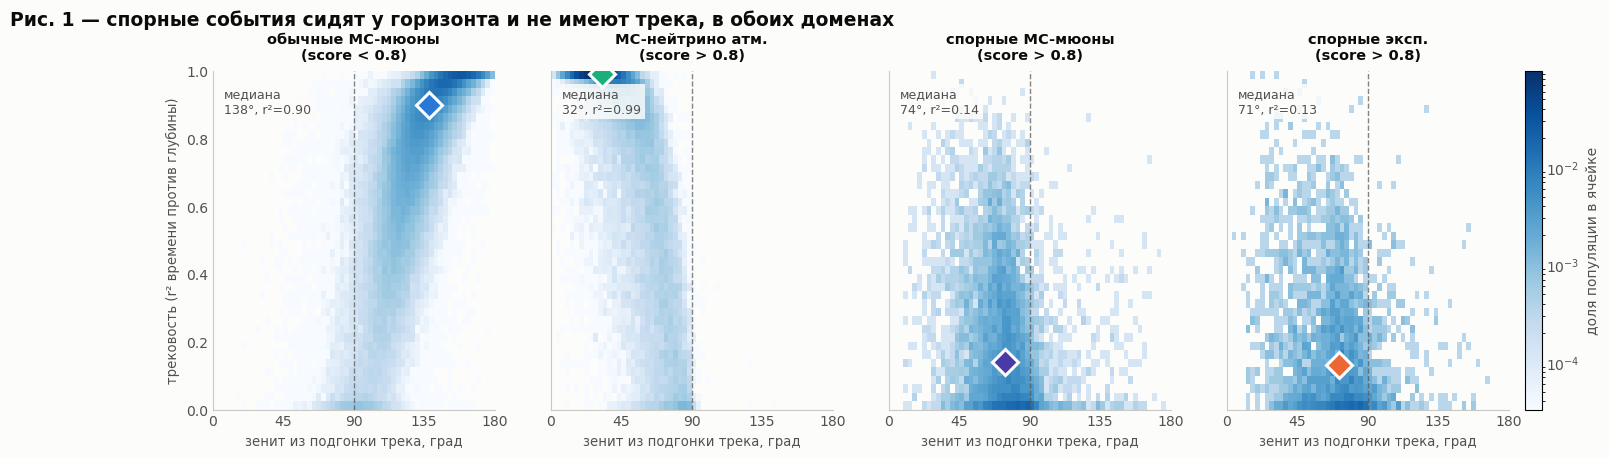

Пунктир — горизонт. В MC мюоны генерируются только ниже него, нейтрино только выше, поэтому именно там классификатору не на что опереться.


In [3]:
POPS = [("обычные MC-мюоны\n(score < 0.8)", g[5], BLUE),
        ("MC-нейтрино атм.\n(score > 0.8)", g[2], AQUA),
        ("спорные MC-мюоны\n(score > 0.8)", g[6], VIOLET),
        ("спорные эксп.\n(score > 0.8)", g[8], ORANGE)]
XE = np.linspace(0, 180, 61)
YE = np.linspace(0, 1, 41)

dens = []
for _, frame, _ in POPS:
    h, _, _ = np.histogram2d(frame.fit_zenith, frame.track_likeness, bins=[XE, YE])
    dens.append(h / h.sum())
vmax = max(d.max() for d in dens)

fig, axes = plt.subplots(1, 4, figsize=(17.2, 4.4), sharex=True, sharey=True)
fig.patch.set_facecolor(SURFACE)
for ax, (name, frame, colour), d in zip(axes, POPS, dens):
    style(ax); ax.grid(False)
    mesh = ax.pcolormesh(XE, YE, d.T, cmap="Blues",
                         norm=LogNorm(vmin=vmax / 3e3, vmax=vmax), shading="flat")
    ax.axvline(90, color=MUTED, linestyle="--", linewidth=1, alpha=0.7)
    ax.plot(frame.fit_zenith.median(), frame.track_likeness.median(), marker="D",
            markersize=13, color=colour, markeredgecolor=SURFACE, markeredgewidth=2.2, zorder=5)
    ax.set_title(name, fontsize=10.5, fontweight="bold", color=INK, pad=8)
    ax.set_xlabel("зенит из подгонки трека, град", color=MUTED, fontsize=9.5)
    ax.text(0.04, 0.95, f"медиана\n{frame.fit_zenith.median():.0f}°, "
            f"r²={frame.track_likeness.median():.2f}", transform=ax.transAxes, va="top",
            fontsize=9, color=MUTED,
            bbox=dict(facecolor=SURFACE, edgecolor="none", alpha=0.85, pad=2.5))
axes[0].set_ylabel("трековость (r² времени против глубины)", color=MUTED, fontsize=9.5)
axes[0].set_xticks([0, 45, 90, 135, 180])
bar = fig.colorbar(mesh, ax=axes, fraction=0.016, pad=0.012)
bar.set_label("доля популяции в ячейке", color=MUTED); bar.ax.tick_params(colors=MUTED, length=0)
fig.suptitle("Рис. 1 — спорные события сидят у горизонта и не имеют трека, в обоих доменах",
             x=0.007, ha="left", fontsize=13.5, fontweight="bold", color=INK, y=1.02)
plt.savefig(HERE / "figures/talk_portrait.png", dpi=150, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print("Пунктир — горизонт. В MC мюоны генерируются только ниже него, нейтрино только выше, "
      "поэтому именно там классификатору не на что опереться.")

**Числа под рисунком, они важнее картинки.**

| | зенит | трековость | dt/dz | ранговая корр. время–глубина |
|---|---|---|---|---|
| обычные MC-мюоны | 138° | 0.90 | −3.76 | −0.94 |
| MC-нейтрино атм. | 32° | 0.99 | +3.83 | +1.00 |
| **спорные MC-мюоны** | **74°** | **0.14** | **+1.59** | **+0.37** |
| **спорные эксп.** | **71°** | **0.13** | **+1.41** | **+0.34** |

Две нижние строки совпадают в пределах нескольких процентов по всем четырём величинам. Это и
есть первое указание, что группы физически одинаковы.

**Оговорка сразу.** Совпадение медиан — необходимое, но не достаточное условие. Полная проверка
на совпадение распределений — шаг 5.

## Шаг 3. Эта популяция есть в симуляции, и почти в том же количестве

Определим её **катами по хитам, без всякой нейросети**:

```
ранговая корр. время–глубина > −0.42   и   трековость < 0.5
```

то есть «свет не идёт сверху вниз по стрингу» и «трека нет». Каты применяются к MC и к данным
одним и тем же кодом.

**Ключевой результат этого шага:** популяция встречается в данных лишь в **1.28 раза** чаще, а
не вдвое. Значит формулировка «в данных таких событий больше» объясняет далеко не всю двойку —
и шаг 4 показывает, где остальное.

**И сразу оговорка, без которой шаг вводит в заблуждение:** «горизонт без трека» — условие
необходимое, но далеко не достаточное. Классификатор принимает лишь 0.72% таких событий в MC.
Между этим катом и спорной популяцией остаётся фактор около 140.

In [4]:
HORIZON = lambda d: ((d.spearman_tz > -0.42) & (d.track_likeness < 0.5)).values

def population(lo, hi):
    n = W[lo] * HORIZON(g[lo]).sum() + W[hi] * HORIZON(g[hi]).sum()
    accepted = W[hi] * HORIZON(g[hi]).sum()
    return n, accepted

n_mc, acc_mc = population(5, 6)
n_exp, acc_exp = population(7, 8)
display(pd.DataFrame([
    {"домен": "симуляция, атм. мюоны", "всего": f"{MU_ALL:,}",
     "прошло физический кат": f"{n_mc:,.0f}", "доля": f"{100*n_mc/MU_ALL:.2f}%",
     "из них принято сетью": f"{acc_mc:,.0f}", "приёмка": f"{100*acc_mc/n_mc:.3f}%"},
    {"домен": "эксперимент", "всего": f"{EXP_ALL:,}",
     "прошло физический кат": f"{n_exp:,.0f}", "доля": f"{100*n_exp/EXP_ALL:.2f}%",
     "из них принято сетью": f"{acc_exp:,.0f}", "приёмка": f"{100*acc_exp/n_exp:.3f}%"}]))
print(f"популяция встречается чаще в  {(n_exp/EXP_ALL)/(n_mc/MU_ALL):.2f}  раза")
print(f"а принимается чаще в          {(acc_exp/n_exp)/(acc_mc/n_mc):.2f}  раза   <-- вот двойка")

,домен,всего,прошло физический кат,доля,из них принято сетью,приёмка
0,"симуляция, атм. мюоны","23,167,718","944,040",4.07%,"6,756",0.716%
1,эксперимент,"3,180,681","165,603",5.21%,"2,654",1.603%


популяция встречается чаще в  1.28  раза
а принимается чаще в          2.24  раза   <-- вот двойка


## Шаг 4. Откуда двойка — и почему простое объяснение не работает

Внутри одного и того же физического ката экспериментальные события ярче симулированных
примерно на 15%. Столько же по всей выборке без всяких катов — это известный дефицит света в
симуляции, не свойство спорной популяции.

**Сначала снимем возражение, которое возникает первым.** Если сравнивать группы, отобранные
*по скору*, заряд расходится в 1.36 раза, а не в 1.15, и это выглядит как настоящее различие
популяций. Это эффект отбора: сеть предпочитает яркие события, поэтому кат по скору вырезает
более сдвинутую часть уже сдвинутого распределения. При отборе без сети расхождение
возвращается к общим 1.15.

**А теперь — почему яркость не объясняет двойку.** Напрашивается цепочка: MC тусклее → приёмка
растёт с яркостью → из данных проходит больше. Она проверяется в одну строку: если механизм
такой, то **при фиксированной яркости приёмка должна сравняться**. Смотрите нижнюю таблицу:
в самой тусклой корзине отношение уже 2.0. Рост до 3.8 к яркому концу реален и добавляется
сверху, но пол в 2.0 яркостью не объясняется вовсе.

Это утверждение было в первой версии данного ноутбука в противоположном виде — «двойка есть
дефицит света, пропущенный через порог». Оно опровергнуто и оставлено видимым, потому что
выглядело убедительно.

In [5]:
def wmedian(lo, hi, mask_fn, col):
    a, b = g[lo][mask_fn(g[lo])][col].values, g[hi][mask_fn(g[hi])][col].values
    v = np.r_[a, b]
    w = np.r_[np.full(len(a), W[lo]), np.full(len(b), W[hi])]
    o = np.argsort(v)
    return float(np.interp(0.5, np.cumsum(w[o]) / w.sum(), v[o]))

everything = lambda d: np.ones(len(d), dtype=bool)
display(pd.DataFrame([
    {"величина": c,
     "отбор по скору (6 против 8)": round(g[8][c].median() / g[6][c].median(), 3),
     "физический кат": round(wmedian(7, 8, HORIZON, c) / wmedian(5, 6, HORIZON, c), 3),
     "вообще без ката": round(wmedian(7, 8, everything, c) / wmedian(5, 6, everything, c), 3)}
    for c in ["q_mean", "q_total", "q_max", "n_hits"]]))
print("Отношение медиан, эксперимент к симуляции. Число хитов совпадает точно — "
      "различие только в свете на хит, и оно одинаково всюду, кроме отбора по скору.")

,величина,отбор по скору (6 против 8),физический кат,вообще без ката
0,q_mean,1.364,1.154,1.128
1,q_total,1.439,1.164,1.183
2,q_max,1.641,1.245,1.292
3,n_hits,1.100,1.000,1.000


Отношение медиан, эксперимент к симуляции. Число хитов совпадает точно — различие только в свете на хит, и оно одинаково всюду, кроме отбора по скору.


In [1]:
BANDS = [("< 3", 0, 3), ("3 – 5", 3, 5), ("5 – 8", 5, 8), ("8 – 15", 8, 15), ("> 15", 15, np.inf)]
rows, centres, r_mc, r_exp = [], [], [], []
for name, lo_q, hi_q in BANDS:
    band = lambda d: HORIZON(d) & (d.q_mean >= lo_q).values & (d.q_mean < hi_q).values
    n_m = W[5] * band(g[5]).sum() + W[6] * band(g[6]).sum()
    n_e = W[7] * band(g[7]).sum() + W[8] * band(g[8]).sum()
    a_m = W[6] * band(g[6]).sum() / n_m
    a_e = W[8] * band(g[8]).sum() / n_e
    rows.append({"заряд на хит, п.э.": name, "событий в MC": f"{n_m:,.0f}",
                 "приёмка MC": f"{100*a_m:.3f}%", "приёмка эксп.": f"{100*a_e:.3f}%",
                 "отношение": round(a_e / a_m, 2)})
    centres.append(name); r_mc.append(100 * a_m); r_exp.append(100 * a_e)
display(pd.DataFrame(rows))
print("Отношение НЕ падает к 1 при фиксированной яркости -> яркость не является механизмом.")

fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.6))
fig.patch.set_facecolor(SURFACE)
ax = style(axes[0])
x = np.arange(len(centres))
ax.bar(x - 0.19, r_mc, 0.38, color=BLUE, label="симуляция, атм. мюоны")
ax.bar(x + 0.19, r_exp, 0.38, color=ORANGE, label="эксперимент")
for i, (m_, e_) in enumerate(zip(r_mc, r_exp)):
    ax.text(i, max(m_, e_) * 1.06, f"×{e_/m_:.1f}", ha="center", fontsize=10,
            fontweight="bold", color=INK)
ax.axhline(0, color=MUTED, linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(centres)
ax.set_xlabel("заряд на хит, п.э.", color=MUTED)
ax.set_ylabel("принято классификатором, %", color=MUTED)
ax.set_ylim(0, max(r_exp) * 1.25)
ax.legend(frameon=False, fontsize=9.5, labelcolor=MUTED)
ax.set_title("отношение не опускается ниже 2 ни в одной корзине", fontsize=11.5,
             fontweight="bold", color=INK)

ax = style(axes[1])
edges = np.logspace(np.log10(1.2), np.log10(60), 46)
for lo, hi, colour, lab in [(5, 6, BLUE, "симуляция"), (7, 8, ORANGE, "эксперимент")]:
    a, b = g[lo][HORIZON(g[lo])].q_mean.values, g[hi][HORIZON(g[hi])].q_mean.values
    w = np.r_[np.full(len(a), W[lo]), np.full(len(b), W[hi])]
    ax.hist(np.r_[a, b], bins=edges, weights=w, density=True, histtype="step",
            linewidth=2.2, color=colour, label=lab)
    ax.axvline(wmedian(lo, hi, HORIZON, "q_mean"), color=colour, linestyle="--",
               linewidth=1.2, alpha=0.75)
ax.set_xscale("log"); ax.set_xticks([1.5, 2, 3, 5, 10, 20, 40])
ax.set_xticklabels(["1.5", "2", "3", "5", "10", "20", "40"])
ax.xaxis.set_minor_formatter(plt.NullFormatter())
ax.set_xlabel("заряд на хит, п.э.  (внутри физического ката)", color=MUTED)
ax.set_ylabel("плотность", color=MUTED)
ax.legend(frameon=False, fontsize=9.5, labelcolor=MUTED)
ax.set_title("одна популяция, сдвинутая на 15% по свету", fontsize=11.5,
             fontweight="bold", color=INK)
fig.suptitle("Рис. 2 — яркость сдвинута на 15%, но доли высокоскоровых событий расходится вдвое даже при "
             "одинаковой яркости",
             x=0.007, ha="left", fontsize=13.5, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.savefig(HERE / "figures/talk_mechanism.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

NameError: name 'np' is not defined

**Что осталось после этого шага.** Двойка не объясняется ни числом событий популяции (×1.28),
ни их яркостью (пол 2.0 при фиксированной яркости). Попытка оценить, какую долю избытка
объясняют все 48 признаков сразу — обучить приёмку на MC, применить к данным, стратифицировать
по предсказанной вероятности — даёт остаток **от 1.35 до 2.04 в зависимости только от семени
модели**. При 7 751 принятом событии против 200 000 с весом 115.8 и приёмке 0.03% оценка
неустойчива, и называть из неё число нельзя.

**Вывод шага, без прикрас:** механизм двойки этим анализом не установлен. Установлено, из чего
избыток состоит (шаги 2–3) и чем он не является (шаг 5).

## Шаг 5. Почему это не новая физика — три проверки

Всё выше совместимо и с тем, что в данных сидит что-то, чего в симуляции нет. Три проверки,
каждая из которых могла дать обратный ответ.

**Разделимость не связана с катом.** Дерево отличает спорные MC-мюоны от спорных
экспериментальных с AUC 0.714. Но то же дерево на **низкоскоринговых** группах — те же классы
под порогом, выборки того же размера, обработка идентичная — даёт **0.731**. Пара над катом
разделяется *хуже*, чем пара под ним. Разделимость есть общее расхождение симуляции и данных, а
не свойство избытка.

**Ничего не лежит вне симуляции.** Isolation forest, обученный на всех группах MC: ниже порога,
отсекающего 1% отложенной симуляции, оказывается 0.1% спорных экспериментальных событий и 0.0%
спорных MC. Обе группы обеднены, ни в одной нет нового хвоста.

**Ни один ран или кластер не несёт больше своей доли.** Разброс отношения по 27 ранам — 0.09,
максимум 1.21; по шести кластерам 0.93–1.06. Приборная гипотеза предсказывала концентрацию, её
нет.

In [7]:
display(pd.DataFrame([
    {"проверка": "разделимость 6 против 8", "результат": "AUC 0.714",
     "контроль": "5 против 7: AUC 0.731", "вывод": "не специфично для ката"},
    {"проверка": "то же, без приборных осей", "результат": "AUC 0.699",
     "контроль": "5 против 7: AUC 0.723", "вывод": "то же"},
    {"проверка": "новизна относительно всей MC", "результат": "0.1% в 1%-хвосте",
     "контроль": "спорные MC: 0.0%", "вывод": "нового нет"},
    {"проверка": "концентрация по ранам", "результат": "разброс 0.09, макс 1.21",
     "контроль": "27 ранов", "вывод": "приборная гипотеза не подтверждается"},
    {"проверка": "нейтриноподобность", "результат": "53.6% спорных эксп.",
     "контроль": "58.6% спорных MC", "вывод": "в данных не более, а менее"},
]))
print("Полные выкладки и перестановочные нули — в groups.ipynb, разделы 4–6.")

,проверка,результат,контроль,вывод
0,разделимость 6 против 8,AUC 0.714,5 против 7: AUC 0.731,не специфично для ката
1,"то же, без приборных осей",AUC 0.699,5 против 7: AUC 0.723,то же
2,новизна относительно всей MC,0.1% в 1%-хвосте,спорные MC: 0.0%,нового нет
3,концентрация по ранам,"разброс 0.09, макс 1.21",27 ранов,приборная гипотеза не подтверждается
4,нейтриноподобность,53.6% спорных эксп.,58.6% спорных MC,"в данных не более, а менее"


Полные выкладки и перестановочные нули — в groups.ipynb, разделы 4–6.


## Что можно и чего нельзя сказать

**Можно.** Избыток состоит из событий, которые симуляция производит. Это горизонтальные события
без трековой структуры, у которых классификатор лишён геометрической опоры: в MC мюоны
генерируются только ниже горизонта, нейтрино только выше, поэтому «нейтрино» для сети означает
«идёт вверх», а у этих событий направление не определено. Популяция встречается в обоих доменах
почти одинаково часто (×1.28), и ничего, чего симуляция не производит, в данных не найдено.

**Нельзя.**

- **Объяснить двойку.** Ни числом событий популяции, ни их яркостью. При фиксированной яркости
  приёмка в данных всё равно вдвое выше. Это главный открытый вопрос, и он остался открытым.
- **Объяснить дефицит света.** 15% — это утверждение о симуляции, и настоящая причина
  лежит вне этого анализа: оптика воды, калибровка, модель отклика ФЭУ.
- **Сказать что-либо о конкретном событии.** «Избыток» — это перевес в счёте: из 3 044 принятых
  экспериментальных событий около 1 546 есть предсказанный фон, но какое из них какое, неизвестно.
  Все утверждения относятся к смеси.
- **Исключить популяцию, спрятанную внутри.** Популяция, распределённая точно как ошибочные
  мюоны и составляющая часть избытка, не была бы видна ничем из перечисленного. Она, впрочем,
  была бы и неотличима от ошибочных мюонов по построению.
- **Дать абсолютную нормировку.** У мюонной симуляции `event_weight` тождественно равен 1 и
  живое время нигде не записано. Все числа — про доли и форму, не про темпы.
- **Считать «горизонт без трека» определением избытка.** Кат отбирает 4% мюонов, из которых
  принимается 0.72%. Он описывает популяцию, но не выделяет её.